In [67]:
import astropy.units as u
import numpy as np
from astropy.modeling.blackbody import blackbody_nu
from scipy.integrate import quad
import matplotlib.pyplot as plt
%matplotlib inline

#### Very simplistic background approximation

One source of background noise in the antenna of a radio telescope is the blackbody radiation of the cosmic mircowave background.

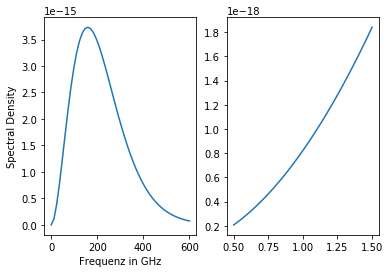

In [72]:
bandwidth = np.linspace(0.5, 1.5) *u.GHz
T = 2.7 * u.K

fig, [ax1, ax2] = plt.subplots(1, 2)
f = np.linspace(0.1, 600) *u.GHz

ax1.plot(f, blackbody_nu(f, T))
ax2.plot(bandwidth, blackbody_nu(bandwidth, T))
ax1.set_xlabel('Frequenz in GHz')
ax1.set_ylabel('Spectral Density')

In [ ]:
spectral_density, _ = quad(lambda x : blackbody_nu(x, T).si.value, bandwidth[0].si.value, bandwidth[-1].si.value)
spectral_density = spectral_density * u.Unit('erg/(cm^2 s sr)')

Total energy deposited into the reflector from the cosmic microwave background. I assume all the energy gets reflected into the sensor.

In [64]:
sample_length = 1 * u.ns
dish_area = 2*np.pi*(12.5 * u.m)**2
fov = 4.5 * u.deg
solid_angle = (2 * np.pi * (1 - np.cos(4.5 * u.deg))) * u.sr
energy_deposited = (spectral_density * sample_length * dish_area * solid_angle).to('joule')
energy_deposited

<Quantity 1.6913886033632336e-23 J>

Let's pretend the signal from the air shower is an incident plane wave with an amplitude of 25 micro Volt per meter into the sensor. 

In [65]:
E_max = 25 *u.Unit('mV/m')
A_sensor = (0.5 * u.m)**2
z = (377*u.Ohm) # free space impedance.
S = 0.5 * 1/(377*u.Ohm) * (E_max**2) * A_sensor * sample_length
S.to('joule')

<Quantity 2.0722811671087533e-16 J>